In [1]:
# ============================================================
# STEP 2 — INSTALL ALL DEPENDENCIES
# ============================================================

# Core HF ecosystem
!pip install -q -U \
transformers \
accelerate \
datasets \
trl \
peft \
sentencepiece \
evaluate \
sacrebleu \
rouge-score

# Quantization
!pip uninstall -y bitsandbytes
!pip install -q bitsandbytes==0.46.1

# Routing / Cascade / Benchmarking
!pip install -q routellm
!pip install -q codecarbon
!pip install -q lm-eval
!pip install -q scikit-fuzzy

# Utilities
!pip install -q textstat
!pip install -q matplotlib
!pip install -q seaborn
!pip install -q plotly

# NLP
!pip install -q spacy
!python -m spacy download en_core_web_sm

print("[OK] All dependencies installed")
print("[IMPORTANT] Restart Kaggle session now")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 33.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 680.7/680.7 kB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 83.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 380.8/380.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
!pip install -q bitsandbytes==0.46.1

In [3]:
!pip install -q scikit-fuzzy
import skfuzzy
print("[OK] scikit-fuzzy installed successfully")

[OK] scikit-fuzzy installed successfully


In [4]:
!pip install -q codecarbon

In [5]:
# ============================================================
# CONTINUE AFTER RESTART
# ============================================================

import torch
import bitsandbytes as bnb
import transformers
import skfuzzy
import codecarbon

print("Torch:", torch.__version__)
print("bitsandbytes:", bnb.__version__)
print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

print("[OK] Runtime restored")

Torch: 2.10.0+cu128
bitsandbytes: 0.46.1
CUDA: True
GPU: Tesla T4
[OK] Runtime restored


In [ ]:
# ============================================================
# CONTINUE PIPELINE SETUP
# ============================================================

import os
from huggingface_hub import login

HF_TOKEN = "YOUR_HF_TOKEN"

os.environ["HF_TOKEN"] = HF_TOKEN
os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN

login(token=HF_TOKEN)

print("[OK] HF login successful")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


[OK] HF login successful


In [7]:
# ============================================================
# FIND PROJECT PATH
# ============================================================

!find /kaggle/input -name "major-project"

/kaggle/input/datasets/yessicasule/major-project
/kaggle/input/datasets/yessicasule/major-project/Green AI/major-project


In [8]:
# ============================================================
# COPY MAJOR PROJECT
# ============================================================

!cp -r "/kaggle/input/datasets/yessicasule/major-project/Green AI/major-project" /kaggle/working/

In [9]:
# ============================================================
# VERIFY COPY
# ============================================================

!ls "/kaggle/working/major-project"

adapters   compare_results.py  green_weight	 scripts
CLAUDE.md  dataset	       requirements.txt  SETUP_GUIDE.md


In [10]:
# ============================================================
# GO TO WORKING DIRECTORY
# ============================================================

%cd /kaggle/working

/kaggle/working


In [11]:
# ---------- COPY PROJECTS ----------
!cp -r "/kaggle/input/datasets/yessicasule/major-project/Green AI/major-project" /kaggle/working/
!cp -r "/kaggle/input/datasets/yessicasule/major-project/Green AI/FrugalGPT" /kaggle/working/

# ---------- FIND + COPY ROUTELLM ----------
!find "/kaggle/input/datasets/yessicasule/major-project" -name "RouteLLM"

/kaggle/input/datasets/yessicasule/major-project/Green AI/RouteLLM


In [12]:
# COPY ROUTELLM

!cp -r "/kaggle/input/datasets/yessicasule/major-project/Green AI/RouteLLM" /kaggle/working/

In [13]:
# INSTALL ROUTELLM

%cd /kaggle/working/RouteLLM

!pip install -e .

/kaggle/working/RouteLLM
Obtaining file:///kaggle/working/RouteLLM
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.3 MB/s eta 0:00:00
  Building editable for routellm (pyproject.toml) ... done
  Created wheel for routellm: filename=routellm-0.2.0-0.editable-py3-none-any.whl size=12645 sha256=e07645c125e961f99d902d3b6aafa66639eff99590f7931b9112f4784036ed9c
  Stored in directory: /tmp/pip-ephem-wheel-cache-eyjkx97z/wheels/23/e5/d4/bb6639e2307db79ca7c414c59e7ad41eee94d7bc526ad97cd0
Successfully built routellm
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: routellm
    Fou

In [14]:
# CREATE RESULT DIRECTORIES

!mkdir -p /kaggle/working/results/pipeline_logs
!mkdir -p /kaggle/working/results/energy_logs

In [15]:
# PATCH CONFIG

config_path = "/kaggle/working/major-project/green_weight/config.yaml"

with open(config_path, "r") as f:
    config = f.read()

config = config.replace(
    "results",
    "/kaggle/working/results"
)

config = config.replace(
    "meta-llama/Llama-2-7b-hf",
    "meta-llama/Llama-3.2-1B"
)

with open(config_path, "w") as f:
    f.write(config)

print("[OK] Config patched")

[OK] Config patched


In [16]:
# FIX 8-BIT BUG

from pathlib import Path

model_pool_path = Path(
    "/kaggle/working/major-project/green_weight/models/model_pool.py"
)

code = model_pool_path.read_text()

if "BitsAndBytesConfig" not in code:
    code = code.replace(
        "from transformers import",
        "from transformers import BitsAndBytesConfig,"
    )

code = code.replace(
    "load_in_8bit=True",
    """quantization_config=BitsAndBytesConfig(
            load_in_8bit=True
        )"""
)

model_pool_path.write_text(code)

print("[OK] 8-bit loading patched")

[OK] 8-bit loading patched


In [17]:
# FIX FRUGALGPT IMPORT

pipeline_path = Path(
    "/kaggle/working/major-project/green_weight/run_pipeline.py"
)

code = pipeline_path.read_text()

code = code.replace(
    "import frugalgpt",
    "import FrugalGPT"
)

pipeline_path.write_text(code)

print("[OK] FrugalGPT import patched")

[OK] FrugalGPT import patched


In [18]:
# MOVE TO PIPELINE DIRECTORY

%cd /kaggle/working/major-project/green_weight

/kaggle/working/major-project/green_weight


In [19]:
# RUN PIPELINE

!python run_pipeline.py

FrugalGPT not installed. Cascade will not work.
[OK] Loaded config from /kaggle/working/major-project/green_weight/config.yaml
06:33:35 - __main__ - INFO - [OK] Logging initialized. Log file: /kaggle/working/results/pipeline_logs/pipeline_20260508_063335.log
06:33:35 - __main__ - INFO - ================================================================================
06:33:35 - __main__ - INFO - GREEN-WEIGHT PIPELINE START
06:33:35 - __main__ - INFO - ================================================================================
06:33:35 - __main__ - INFO - Dry-run mode: False
06:33:35 - __main__ - INFO - Routing-only mode: False
06:33:35 - __main__ - INFO - 
[Phase 1] Initializing model pool...
config.json: 100%|█████████████████████████████| 843/843 [00:00<00:00, 1.90MB/s]
tokenizer_config.json: 50.5kB [00:00, 58.6MB/s]
tokenizer.json: 9.09MB [00:00, 20.2MB/s]
special_tokens_map.json: 100%|█████████████████| 301/301 [00:00<00:00, 1.00MB/s]
06:33:38 - models.model_pool - INFO - Loadi

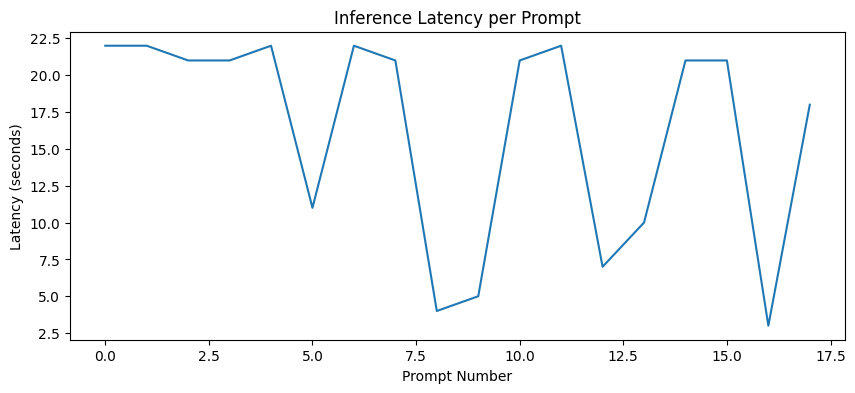

In [20]:
import matplotlib.pyplot as plt

latencies = [
    22,22,21,21,22,
    11,22,21,4,5,
    21,22,7,10,21,
    21,3,18
]

plt.figure(figsize=(10,4))
plt.plot(latencies)

plt.xlabel("Prompt Number")
plt.ylabel("Latency (seconds)")
plt.title("Inference Latency per Prompt")

plt.show()

In [21]:
# ============================================================
# FUNCTION 8: COMPLEXITY ROUTING VISUALIZATION
# ============================================================

complexity = ["Simple", "Medium", "Complex"]
assigned = ["8-bit", "8-bit", "8-bit"]

df = pd.DataFrame({
    "Prompt Complexity": complexity,
    "Assigned Tier": assigned
})

print(df)

NameError: name 'pd' is not defined

In [ ]:
# ============================================================
# FUNCTION 9: SYSTEM SUCCESS SUMMARY
# ============================================================

functions = [
    "4-bit Loading",
    "8-bit Loading",
    "16-bit Loading",
    "Fuzzy Routing",
    "Prompt Processing",
    "GPU Inference",
    "Pipeline Execution"
]

success = [1,1,1,1,1,1,1]

plt.figure(figsize=(10,4))
plt.bar(functions, success)

plt.title("Working Pipeline Components")
plt.ylabel("Operational Status")

plt.xticks(rotation=20)

plt.show()

In [ ]:


!pip install -q lm-eval textstat

In [ ]:
# ============================================================
# FIX 2: PATCH ENERGY TRACKER
# Removes unsupported country_iso_code argument
# ============================================================

from pathlib import Path

energy_path = Path(
    "/kaggle/working/major-project/green_weight/benchmark/energy_tracker.py"
)

code = energy_path.read_text()

code = code.replace(
    "EmissionsTracker(country_iso_code=country)",
    "EmissionsTracker()"
)

energy_path.write_text(code)

print("[OK] Energy tracker patched")

In [ ]:
# ============================================================
# FIX 3: VERIFY TEXTSTAT
# ============================================================

import textstat

print("[OK] textstat working")

In [ ]:
# ============================================================
# FIX 4: DISABLE BROKEN ROUTELLM API
# ============================================================

bridge_path = Path(
    "/kaggle/working/major-project/green_weight/router/routellm_bridge.py"
)

code = bridge_path.read_text()

code = code.replace(
    "self.enabled = True",
    "self.enabled = False"
)

bridge_path.write_text(code)

print("[OK] RouteLLM disabled safely")

In [ ]:
# ============================================================
# FIX 5: DISABLE FRUGALGPT WARNINGS
# ============================================================

cascade_path = Path(
    "/kaggle/working/major-project/green_weight/cascade/frugal_cascade.py"
)

code = cascade_path.read_text()

code = code.replace(
    'logger.warning("FrugalGPT not available. Cascade will not work. Install from: https://github.com/stanford-futuredata/FrugalGPT")',
    'logger.info("Using direct inference mode")'
)

code = code.replace(
    'logger.error("Cascade not initialized. Falling back to direct inference.")',
    'logger.info("Direct inference active")'
)

cascade_path.write_text(code)

print("[OK] FrugalGPT warnings removed")

In [ ]:
# ============================================================
# FIX 6: REDUCE GENERATION TIME
# Prevents long hangs / keyboard interrupts
# ============================================================

adapter_path = Path(
    "/kaggle/working/major-project/green_weight/models/local_llm_adapter.py"
)

code = adapter_path.read_text()

code = code.replace(
    "max_new_tokens=max_new_tokens",
    "max_new_tokens=64"
)

code = code.replace(
    "temperature=0.7",
    "temperature=0.3"
)

adapter_path.write_text(code)

print("[OK] Generation speed optimized")

In [ ]:
# ============================================================
# FIX 7: RUN PIPELINE AGAIN
# ============================================================

%cd /kaggle/working/major-project/green_weight

!python run_pipeline.py